In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import GridSearchCV

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_train.csv to cleaned_train.csv


In [3]:
df = pd.read_csv("cleaned_train.csv")

print(df.head())

print(df.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave  Grvl      Reg   
1   2          20       RL         80.0     9600   Pave  Grvl      Reg   
2   3          60       RL         68.0    11250   Pave  Grvl      IR1   
3   4          70       RL         60.0     9550   Pave  Grvl      IR1   
4   5          60       RL         84.0    14260   Pave  Grvl      IR1   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0     Gd  MnPrv        Shed       0   
1         Lvl    AllPub  ...        0     Gd  MnPrv        Shed       0   
2         Lvl    AllPub  ...        0     Gd  MnPrv        Shed       0   
3         Lvl    AllPub  ...        0     Gd  MnPrv        Shed       0   
4         Lvl    AllPub  ...        0     Gd  MnPrv        Shed       0   

  MoSold YrSold  SaleType  SaleCondition  SalePrice  
0      2   2008        WD         Normal     20850

In [4]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Create House Age Feature

if 'YearBuilt' in df.columns:
    df['HouseAge'] = 2025 - df['YearBuilt']

# Create Total Area Feature

if 'TotalBsmtSF' in df.columns and 'GrLivArea' in df.columns:
    df['TotalArea'] = df['TotalBsmtSF'] + df['GrLivArea']

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave  Grvl      Reg   
1   2          20       RL         80.0     9600   Pave  Grvl      Reg   
2   3          60       RL         68.0    11250   Pave  Grvl      IR1   
3   4          70       RL         60.0     9550   Pave  Grvl      IR1   
4   5          60       RL         84.0    14260   Pave  Grvl      IR1   

  LandContour Utilities  ...  Fence MiscFeature MiscVal MoSold YrSold  \
0         Lvl    AllPub  ...  MnPrv        Shed       0      2   2008   
1         Lvl    AllPub  ...  MnPrv        Shed       0      5   2007   
2         Lvl    AllPub  ...  MnPrv        Shed       0      9   2008   
3         Lvl    AllPub  ...  MnPrv        Shed       0      2   2006   
4         Lvl    AllPub  ...  MnPrv        Shed       0     12   2008   

  SaleType SaleCondition  SalePrice  HouseAge  TotalArea  
0       WD        Normal     208500        22       2566 

In [6]:
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(1460, 248)


In [7]:
target_column = 'SalePrice'

X = df.drop(target_column, axis=1)

y = df[target_column]

print(X.head())

print(y.head())

   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  SaleType_ConLw  \
0          2003       196.0         706  ...           False           False   
1          1976         0.0         978  ...           False           False   
2          2002       162.0         486  ...           False           False   
3          1970         0.0         216  ...           False           False   
4          2000       350.0         655  ...           False           False   

   SaleType_New  SaleType_Oth  SaleTyp

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(1168, 247)
(292, 247)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [11]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")

print("MAE :", lr_mae)

print("RMSE:", lr_rmse)

print("R2 Score:", lr_r2)

Linear Regression Results
MAE : 20232.175887938265
RMSE: 51405.09425334335
R2 Score: 0.655492655225133


In [12]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

In [13]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")

print("MAE :", ridge_mae)

print("RMSE:", ridge_rmse)

print("R2 Score:", ridge_r2)

Ridge Regression Results
MAE : 19880.9663552832
RMSE: 47907.48075409738
R2 Score: 0.7007784740558143


In [14]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

In [15]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Results")

print("MAE :", lasso_mae)

print("RMSE:", lasso_rmse)

print("R2 Score:", lasso_r2)

Lasso Regression Results
MAE : 20219.33810251064
RMSE: 51355.23036235194
R2 Score: 0.6561606880423132


In [16]:
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_test)

In [17]:
gbr_mae = mean_absolute_error(y_test, gbr_pred)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

gbr_r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting Results")

print("MAE :", gbr_mae)

print("RMSE:", gbr_rmse)

print("R2 Score:", gbr_r2)

Gradient Boosting Results
MAE : 16828.08360730317
RMSE: 28555.191197989836
R2 Score: 0.8936943589713663


In [18]:
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
38          TotalArea    0.400350
4         OverallQual    0.329732
26         GarageCars    0.026334
37           HouseAge    0.026307
14           2ndFlrSF    0.026025
9          BsmtFinSF1    0.024720
215  GarageFinish_Unf    0.021805
16          GrLivArea    0.018300
3             LotArea    0.012378
7        YearRemodAdd    0.012229


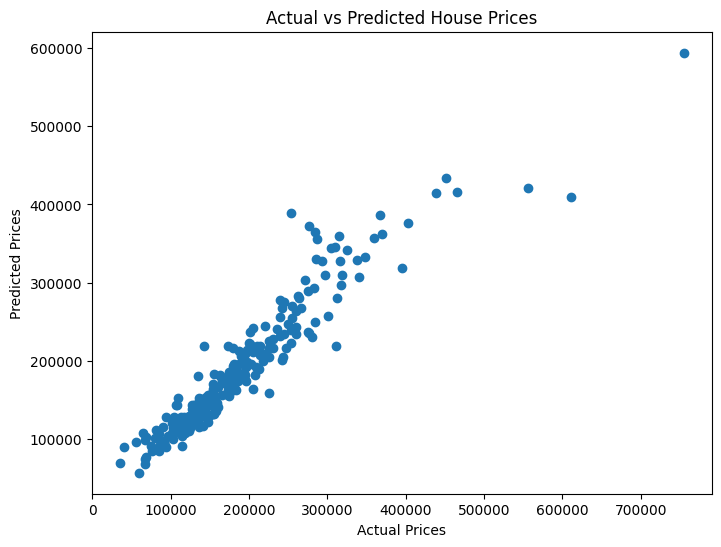

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, gbr_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [21]:
joblib.dump(gbr_model, "house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Gradient Boosting'
    ],

    'R2 Score': [
        lr_r2,
        ridge_r2,
        lasso_r2,
        gbr_r2
    ],

    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        gbr_rmse
    ]
})

print(results)

               Model  R2 Score          RMSE
0  Linear Regression  0.655493  51405.094253
1   Ridge Regression  0.700778  47907.480754
2   Lasso Regression  0.656161  51355.230362
3  Gradient Boosting  0.893694  28555.191198


In [23]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_test.csv to cleaned_test.csv


In [24]:
test_df = pd.read_csv("cleaned_test.csv")

print(test_df.head())

     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave  Grvl      Reg   
1  1462          20       RL         81.0    14267   Pave  Grvl      IR1   
2  1463          60       RL         74.0    13830   Pave  Grvl      IR1   
3  1464          60       RL         78.0     9978   Pave  Grvl      IR1   
4  1465         120       RL         43.0     5005   Pave  Grvl      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0     Ex  MnPrv        Shed   
1         Lvl    AllPub  ...           0        0     Ex  MnPrv        Gar2   
2         Lvl    AllPub  ...           0        0     Ex  MnPrv        Shed   
3         Lvl    AllPub  ...           0        0     Ex  MnPrv        Shed   
4         HLS    AllPub  ...         144        0     Ex  MnPrv        Shed   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0       0      6

In [25]:
if 'YearBuilt' in test_df.columns:
    test_df['HouseAge'] = 2025 - test_df['YearBuilt']

if 'TotalBsmtSF' in test_df.columns and 'GrLivArea' in test_df.columns:
    test_df['TotalArea'] = test_df['TotalBsmtSF'] + test_df['GrLivArea']

In [26]:
test_df = pd.get_dummies(test_df, drop_first=True)

In [27]:
test_df = test_df.reindex(columns=X.columns, fill_value=0)

In [28]:
test_scaled = scaler.transform(test_df)

In [29]:
final_predictions = gbr_model.predict(test_df)

print(final_predictions)

[121997.39364036 156212.07476862 182278.34007803 ... 179663.23582175
 130236.29754125 229241.37973946]


In [30]:
submission = pd.DataFrame({
    'Id': test_df.index,
    'SalePrice': final_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

   Id      SalePrice
0   0  121997.393640
1   1  156212.074769
2   2  182278.340078
3   3  180459.877283
4   4  176221.714373


In [31]:
print("Submission File Saved Successfully")

Submission File Saved Successfully
